#Segmentasi Pelanggan Menggunakan K-Means

Nama  : Hadhist Rizqi Fauzhi

NIM   : 250401020093

Kelas : IF405

### Import Library

In [16]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

plt.style.use("default")

### Langkah 1 - Generate dan Eksplorasi Dataset

In [17]:
# Generate dataset sintetis pelanggan

np.random.seed(42)

grp1 = np.random.normal([30, 20], [6, 8], (100, 2))
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))

data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(
    data,
    columns=["pendapatan_tahunan", "skor_belanja"]
)

df["usia"] = np.random.randint(18, 65, len(df))
df["gender"] = np.random.choice(["L", "P"], len(df))

In [18]:
print("Jumlah Data dan Kolom")
print("Shape:", df.shape)

print("\nInformasi Dataset")
print(df.info())

print("\nStatistik Deskriptif")
print(df.describe().round(2))

print("\n5 Data Pertama")
display(df.head())

Jumlah Data dan Kolom
Shape: (300, 4)

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   pendapatan_tahunan  300 non-null    float64
 1   skor_belanja        300 non-null    float64
 2   usia                300 non-null    int64  
 3   gender              300 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 9.5+ KB
None

Statistik Deskriptif
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00

5 Data Pertama


,pendapatan_tahunan,skor_belanja,usia,gender
0,32.980285,18.893886,64,P
1,33.886131,32.184239,21,P
2,28.595080,18.126904,29,L
3,39.475277,26.139478,62,L
4,27.183154,24.340480,19,L


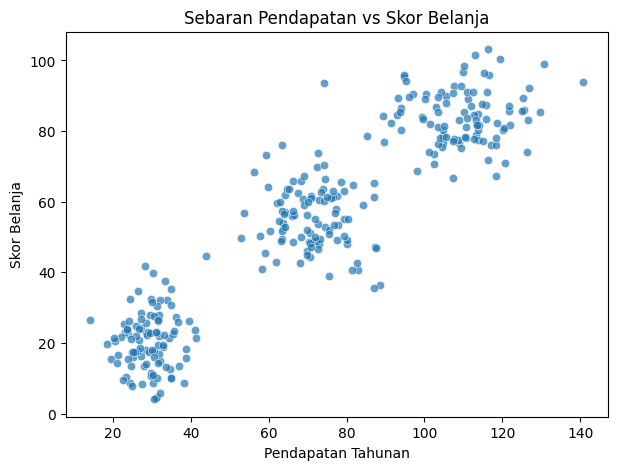

In [19]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="pendapatan_tahunan",
    y="skor_belanja",
    alpha=0.7
)

plt.title("Sebaran Pendapatan vs Skor Belanja")
plt.xlabel("Pendapatan Tahunan")
plt.ylabel("Skor Belanja")

plt.show()

Interpretasi

Berdasarkan visualisasi awal terlihat adanya beberapa kelompok data yang mulai terpisah berdasarkan pendapatan tahunan dan skor belanja. Hal ini menunjukkan bahwa dataset memiliki pola alami sehingga cocok digunakan untuk proses clustering menggunakan algoritma K-Means.

### Langkah 2 - Preprocessing Data

In [20]:
X = df[
    [
        "pendapatan_tahunan",
        "skor_belanja"
    ]
].values

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Rata-rata setelah scaling:")
print(np.round(X_scaled.mean(axis=0),3))

print("\nStandar deviasi setelah scaling:")
print(np.round(X_scaled.std(axis=0),3))

Rata-rata setelah scaling:
[-0.  0.]

Standar deviasi setelah scaling:
[1. 1.]


Interpretasi

StandardScaler digunakan agar seluruh fitur memiliki skala yang sama. Setelah proses scaling, rata-rata setiap fitur mendekati 0 dan standar deviasi mendekati 1 sehingga tidak ada fitur yang lebih dominan saat proses clustering.

### Langkah 3 - Menentukan Jumlah Cluster dengan Metode Elbow

In [21]:
wcss = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        init="k-means++"
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

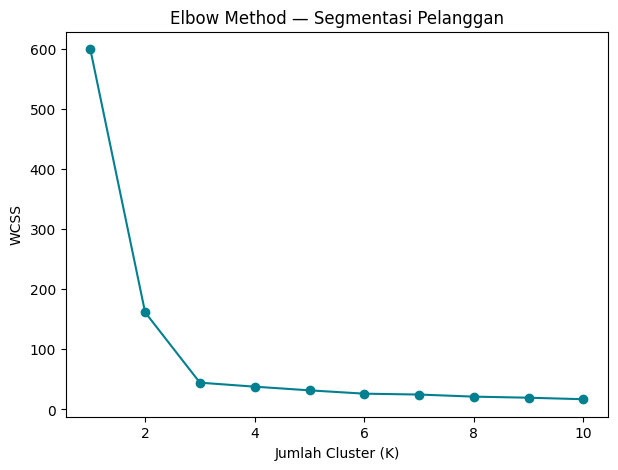

In [22]:
plt.figure(figsize=(7,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o",
    color="#028090"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method — Segmentasi Pelanggan")

plt.show()

Interpretasi Metode Elbow

Dari grafik Elbow terlihat bahwa penurunan nilai WCSS mulai melandai pada **K = 3**. Titik tersebut dipilih sebagai jumlah cluster optimal karena setelah itu penurunan WCSS tidak lagi terlalu signifikan.

Hasil ini sesuai dengan dataset sintetis yang memang dibuat memiliki tiga kelompok pelanggan berbeda.

### Langkah 4 - Melatih Model K-Means

In [23]:
model = KMeans(
    n_clusters=3,
    random_state=42,
    init="k-means++"
)

model.fit(X_scaled)

df["cluster"] = model.labels_

In [24]:
print(f"WCSS Akhir : {model.inertia_:.3f}")

score = silhouette_score(
    X_scaled,
    model.labels_
)

print(f"Silhouette Score : {score:.3f}")

print("\nRata-rata setiap cluster")

print(
    df.groupby("cluster")[
        ["pendapatan_tahunan","skor_belanja"]
    ].mean().round(2)
)

WCSS Akhir : 44.556
Silhouette Score : 0.695

Rata-rata setiap cluster
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


Interpretasi

Nilai Silhouette Score menunjukkan kualitas pembentukan cluster. Semakin mendekati 1 maka pemisahan antar cluster semakin baik. Berdasarkan hasil yang diperoleh, model mampu memisahkan pelanggan menjadi tiga kelompok yang cukup jelas.

### Langkah 5 - Visualisasi Hasil Clustering

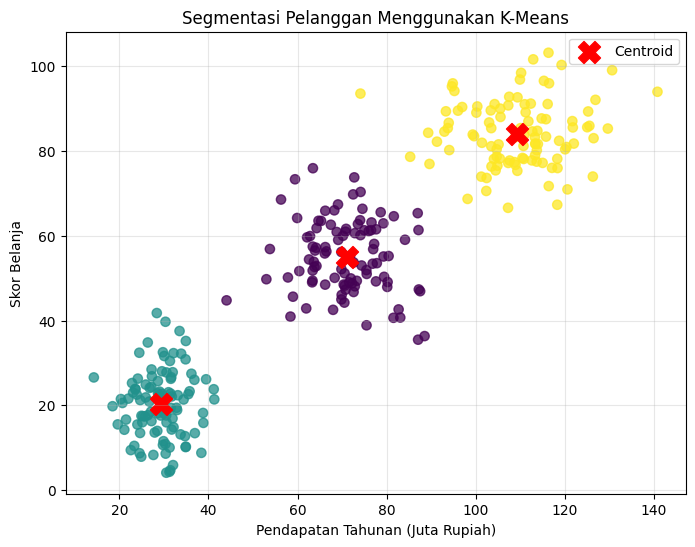

In [27]:
centroids = scaler.inverse_transform(
    model.cluster_centers_
)

plt.figure(figsize=(8,6))

plt.scatter(
    df["pendapatan_tahunan"],
    df["skor_belanja"],
    c=df["cluster"],
    cmap="viridis",
    s=45,
    alpha=0.75
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c="red",
    marker="X",
    s=250,
    label="Centroid"
)

plt.grid(alpha=0.3)
plt.xlabel("Pendapatan Tahunan (Juta Rupiah)")

plt.ylabel("Skor Belanja")

plt.title("Segmentasi Pelanggan Menggunakan K-Means")

plt.legend()
plt.show()

Interpretasi Hasil Clustering

Berdasarkan visualisasi diperoleh tiga segmen pelanggan:

- **Cluster 0** memiliki pendapatan rendah dan skor belanja rendah sehingga dapat dikategorikan sebagai pelanggan **Hemat**.
- **Cluster 1** memiliki pendapatan dan skor belanja pada tingkat menengah sehingga termasuk pelanggan **Menengah**.
- **Cluster 2** memiliki pendapatan tinggi serta skor belanja tinggi sehingga termasuk pelanggan **Premium atau Boros**.

Posisi centroid berada di tengah masing-masing kelompok sehingga menunjukkan bahwa proses clustering berjalan dengan baik.

### Langkah 6 - Hierarchical Clustering

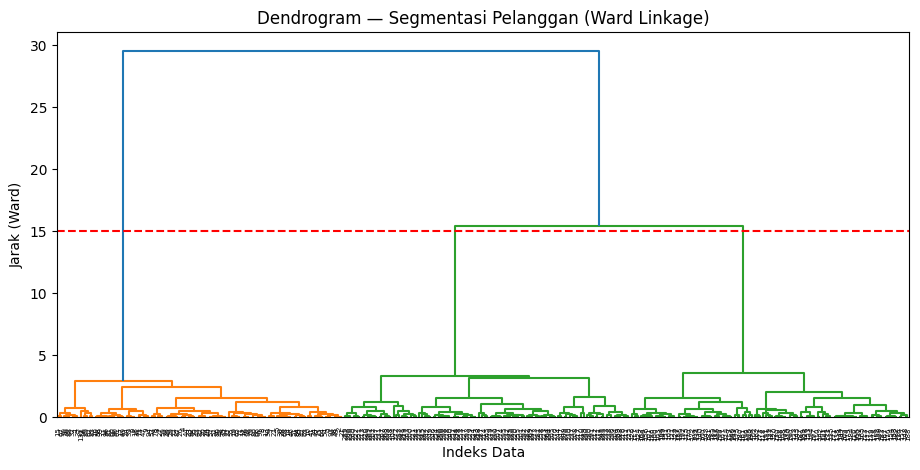

In [26]:
Z = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(11,5))

dendrogram(Z)

plt.axhline(
    y=15,
    color="red",
    linestyle="--"
)

plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')

plt.xlabel("Indeks Data")

plt.ylabel("Jarak (Ward)")

plt.show()

Interpretasi Hierarchical Clustering

Dendrogram menunjukkan bahwa data secara alami dapat dipisahkan menjadi sekitar tiga kelompok ketika garis potong diterapkan pada jarak tertentu. Hasil tersebut konsisten dengan Metode Elbow yang juga menunjukkan jumlah cluster optimal sebanyak tiga. Dengan demikian, baik K-Means maupun Hierarchical Clustering menghasilkan segmentasi yang serupa pada dataset ini.

### Kesimpulan

Pada praktikum ini dilakukan segmentasi pelanggan menggunakan algoritma K-Means dengan tahapan mulai dari pembuatan dataset sintetis, eksplorasi data, preprocessing menggunakan StandardScaler, penentuan jumlah cluster melalui Metode Elbow, pelatihan model, visualisasi hasil clustering, hingga perbandingan menggunakan Hierarchical Clustering.

Berdasarkan grafik Elbow diperoleh jumlah cluster optimal sebanyak **3 cluster**, sesuai dengan karakteristik dataset yang memang memiliki tiga kelompok pelanggan. Nilai Silhouette Score menunjukkan bahwa hasil clustering memiliki kualitas yang baik, sedangkan visualisasi memperlihatkan pemisahan cluster yang cukup jelas. Ketiga cluster dapat diinterpretasikan sebagai pelanggan **Hemat**, **Menengah**, dan **Premium/Boros** berdasarkan kombinasi pendapatan tahunan dan skor belanja.

Perbandingan menggunakan Hierarchical Clustering melalui dendrogram juga menghasilkan jumlah kelompok yang konsisten dengan K-Means. Hal ini menunjukkan bahwa kedua metode mampu mengidentifikasi struktur alami pada data sehingga dapat digunakan sebagai dasar dalam melakukan segmentasi pelanggan untuk mendukung strategi pemasaran yang lebih tepat sasaran.